In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from src.data import load_simple_price_csv

# Ensure the project root is in the path (adjust if your notebook is in a subfolder)
sys.path.append(str(Path.cwd()))

# 1. Core Configuration & Models
from src.core.asset import Asset
from src.core.capital import Capital, FixedCapitalModel
from src.core.sizers import FixedFractionSizer

# 2. Strategies
from src.strategies.buy_and_hold import BuyAndHoldStrategy

# 3. Engine & Analyzer
from src.engine.vectorized import VectorizedEngine
from src.engine.analyzer import PerformanceAnalyzer

# 4. Visualization
from src.plots.plotter import plot_backtest_results

print("✅ All imports successful!")

ImportError: cannot import name 'Capital' from 'src.core.asset' (c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies\src\core\asset.py)

In [ ]:
data = load_simple_price_csv('./data/MCFTR.csv')

In [ ]:
data.head()

0
2003-02-26    335.67
2003-02-27    338.35
2003-02-28    341.52
2003-03-03    352.24
2003-03-04    348.40
Name: UNKNOWN, dtype: float64

In [ ]:
asset = Asset(ticker="MCFTR", price_data=data, point_value=1.0, commission_rate=0.001, trading_days=252)
capital = Capital(initial_capital=100_000.0)
strategy = BuyAndHoldStrategy()

engine = VectorizedEngine(capital=capital) # Uses default FixedFractionSizer
execution_result = engine.run(strategy=strategy, asset=asset)
print(f"✅ Backtest complete! Final Equity: ${execution_result.equity.iloc[-1]:,.2f}")

✅ Backtest complete! Final Equity: $406,771.75


In [ ]:
analyzer = PerformanceAnalyzer()
metrics = analyzer.analyze(execution_result)

print("\n--- Performance Metrics ---")
print(f"Total Return: {metrics.total_return_pct:>8.2f}%")
print(f"CAGR:         {metrics.cagr_pct:>8.2f}%")
print(f"Sharpe Ratio: {metrics.sharpe_ratio:>8.2f}")
print(f"Max Drawdown: {metrics.max_drawdown_pct:>8.2f}%")
print(f"Win Rate:     {metrics.win_rate_pct:>8.2f}%")
print(f"Total Fees:   ${metrics.total_fees_currency:>8.2f}")


--- Performance Metrics ---
Total Return:   306.77%
CAGR:            13.45%
Sharpe Ratio:     0.37
Max Drawdown:  -141.43%
Win Rate:        53.60%
Total Fees:   $ 7006.81


c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies\src\plots\plotter.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


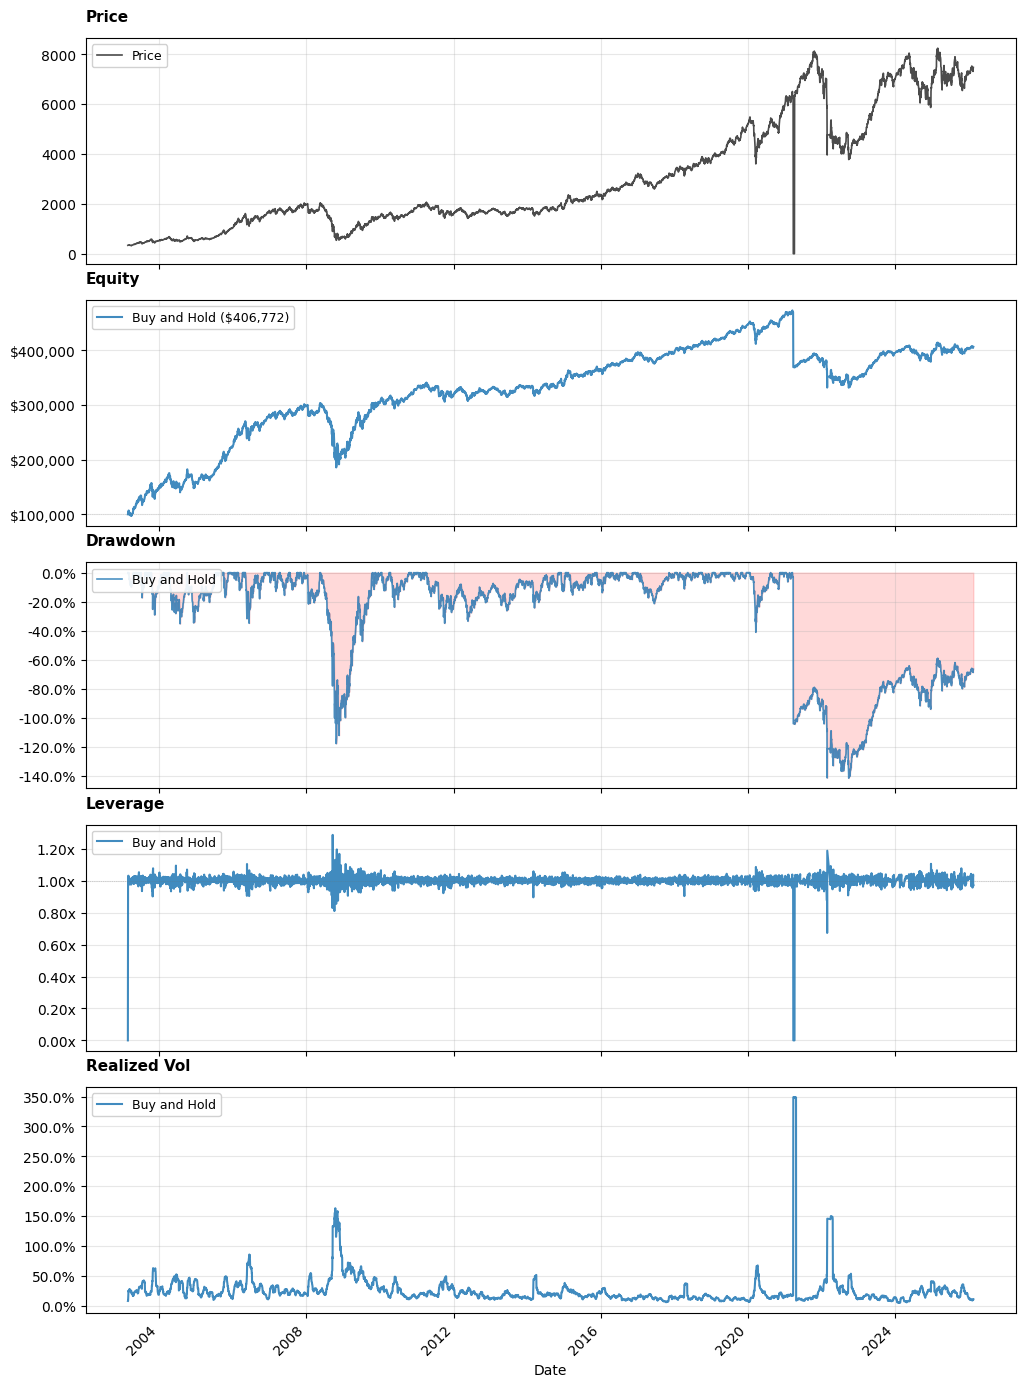

In [ ]:
plot_backtest_results(
    results=execution_result,
    panels=['price', 'equity', 'drawdown', 'leverage', 'realized_vol'],
    plot_pct=False,
    figsize_base=(12, 3)
)